In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
import h3

In [2]:
offers_df = pd.read_csv("data_offers.csv")
offers_df.head()

,order_gk,offer_id
0,3000579625629,300050936206
1,3000627306450,300052064651
2,3000632920686,300052408812
3,3000632771725,300052393030
4,3000583467642,300051001196


In [3]:
offers_df.shape

(334363, 2)

In [4]:
offers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 334363 entries, 0 to 334362
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   order_gk  334363 non-null  int64
 1   offer_id  334363 non-null  int64
dtypes: int64(2)
memory usage: 5.1 MB


In [5]:
orders_df = pd.read_csv("data_orders.csv")
orders_df.head()


,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0
1,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0
2,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0
3,13:50:20,-1.054671,51.460544,658.0,3000582941169,4,1,62.0
4,21:24:45,-0.967605,51.458236,NaN,3000583140877,9,0,NaN


In [6]:
orders_df['order_datetime'] = pd.to_datetime(orders_df['order_datetime'], format='%H:%M:%S')


In [7]:
orders_df.shape

(10716, 8)

In [8]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10716 entries, 0 to 10715
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_datetime                 10716 non-null  datetime64[us]
 1   origin_longitude               10716 non-null  float64       
 2   origin_latitude                10716 non-null  float64       
 3   m_order_eta                    2814 non-null   float64       
 4   order_gk                       10716 non-null  int64         
 5   order_status_key               10716 non-null  int64         
 6   is_driver_assigned_key         10716 non-null  int64         
 7   cancellations_time_in_seconds  7307 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(3)
memory usage: 669.9 KB


In [9]:
df = orders_df.merge(offers_df,"inner","order_gk")
df.shape

(31268, 9)

In [10]:
df['is_driver_assigned_key']=df['is_driver_assigned_key'].replace(
    {0:"No",
     1:"Yes"}
)


In [11]:
df['order_status_key']=df['order_status_key'].replace(
    {4:"Client Cancelled",
     9:"System Rejected"}
)

## Build up distribution of orders according to reasons for failure: cancellations before and after driver assignment, and reasons for order rejection. 
#### Analyse the resulting plot. Which category has the highest number of orders?

In [12]:
pd.crosstab(df['order_status_key'], df['is_driver_assigned_key'])

is_driver_assigned_key,No,Yes
order_status_key,,
Client Cancelled,13435,8360
System Rejected,9469,4


In [13]:
df.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds,offer_id
0,1900-01-01 18:08:07,-0.978916,51.456173,60.0,3000583041974,Client Cancelled,Yes,198.0,300050983403
1,1900-01-01 20:57:32,-0.950385,51.456843,NaN,3000583116437,Client Cancelled,No,128.0,300050986179
2,1900-01-01 20:57:32,-0.950385,51.456843,NaN,3000583116437,Client Cancelled,No,128.0,300050986174
3,1900-01-01 20:57:32,-0.950385,51.456843,NaN,3000583116437,Client Cancelled,No,128.0,300050986180
4,1900-01-01 12:07:50,-0.969520,51.455544,477.0,3000582891479,Client Cancelled,Yes,46.0,300050976275


In [14]:
cancelled_before_assignment = df.loc[(df['is_driver_assigned_key'] == 'No')&(df['order_status_key'] == 'Client Cancelled')]
cancelled_after_assignment = df.loc[(df['is_driver_assigned_key']=='Yes') &(df['order_status_key'] == 'Client Cancelled')]
rejected_by_system_before_assigment = df.loc[(df['is_driver_assigned_key']=='No') & (df['order_status_key']=='System Rejected')]
rejected_by_system_after_assigment = df.loc[(df['is_driver_assigned_key']=='Yes') & (df['order_status_key']=='System Rejected')]

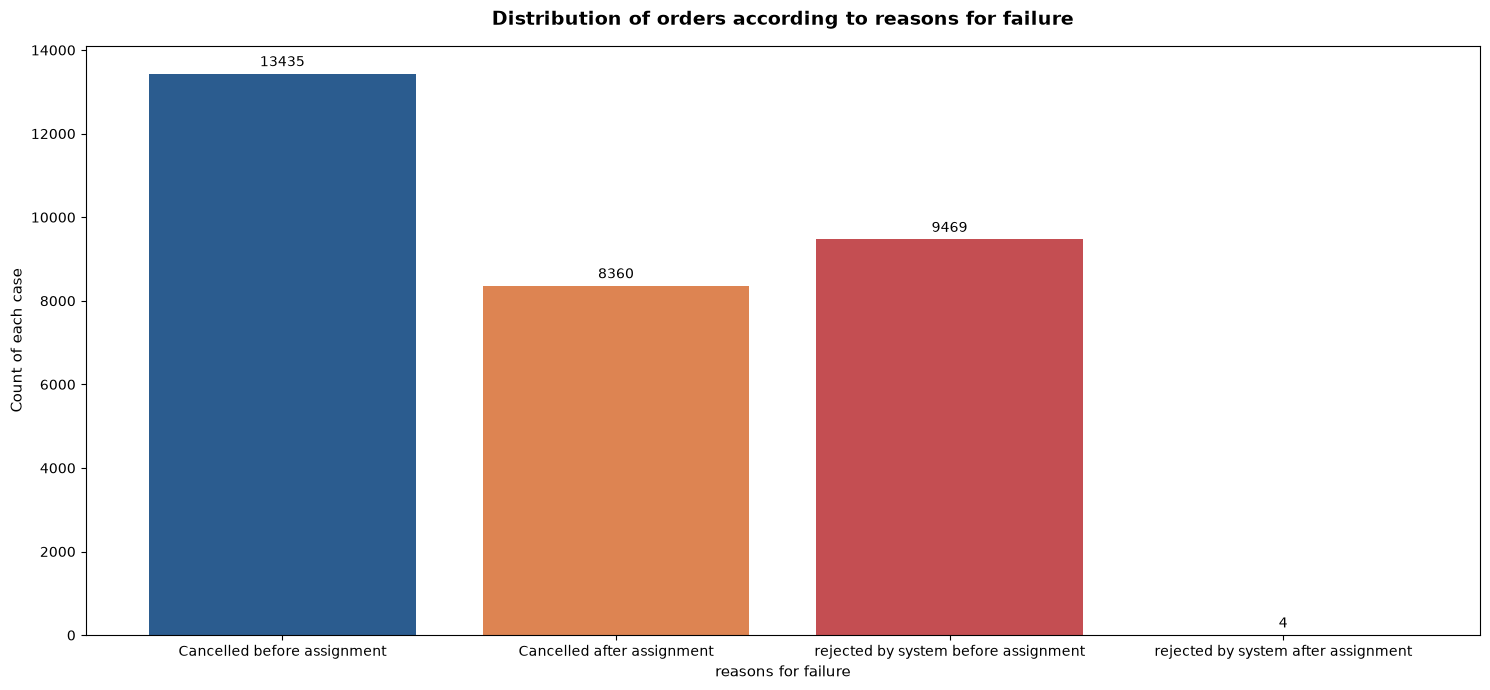

In [15]:
reasons_of_failures = pd.Series({
    "Cancelled before assignment" : len(cancelled_before_assignment),
    "Cancelled after assignment"  : len(cancelled_after_assignment),
    "rejected by system before assignment" : len(rejected_by_system_before_assigment),
    "rejected by system after assignment" : len(rejected_by_system_after_assigment)
    }
)


plt.figure(figsize=(15,7))
bars = plt.bar(x=reasons_of_failures.index, height=reasons_of_failures.values, color=["#2b5c8f", "#DD8452", "#C44E52"])

plt.bar_label(bars, padding=3)
plt.title("Distribution of orders according to reasons for failure",fontsize=14, pad=15, fontweight='bold')
plt.xlabel("reasons for failure", fontsize=11)
plt.ylabel("Count of each case", fontsize=11)
plt.tight_layout()
plt.show()

## Plot the distribution of failed orders by hours
#### Is there a trend that certain hours have an abnormally high proportion of one category or another? What hours are the biggest fails? How can this be explained?


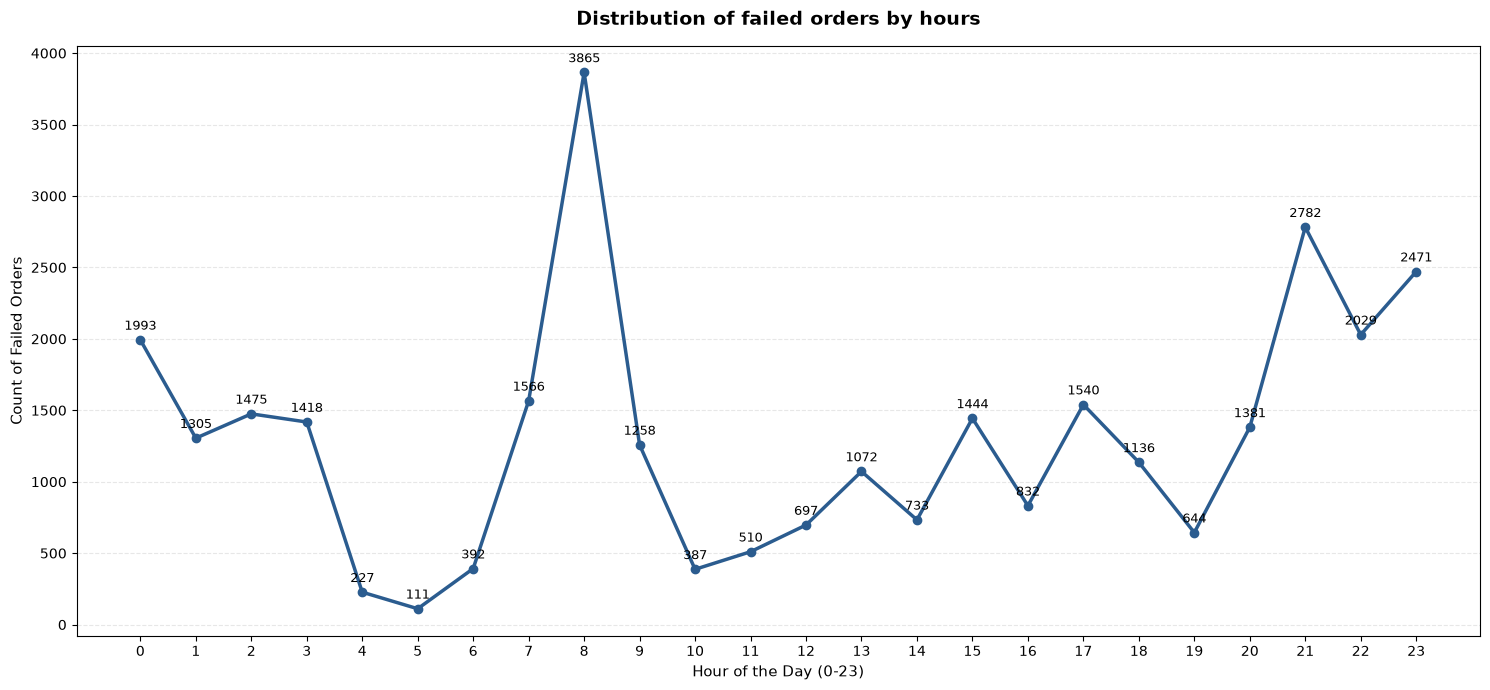

In [16]:

df_grouped_by_hour = df.groupby(df['order_datetime'].dt.hour).size()
plt.figure(figsize=(15,7))
plt.plot(df_grouped_by_hour.index, df_grouped_by_hour.values, color="#2b5c8f", linewidth=2.5, marker='o')
for x, y in zip(df_grouped_by_hour.index, df_grouped_by_hour.values):
    plt.text(x, y + 50, str(y), ha='center', va='bottom', fontsize=9)

plt.xticks(range(0,24))
plt.title("Distribution of failed orders by hours",fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Hour of the Day (0-23)", fontsize=11)
plt.ylabel("Count of Failed Orders", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

hour  is_driver_assigned_key  order_status_key
0     No                      Client Cancelled     957
                              System Rejected      706
      Yes                     Client Cancelled     326
                              System Rejected        4
1     No                      Client Cancelled     633
                                                  ... 
22    No                      System Rejected      660
      Yes                     Client Cancelled     415
23    No                      Client Cancelled    1144
                              System Rejected      883
      Yes                     Client Cancelled     444
Length: 73, dtype: int64


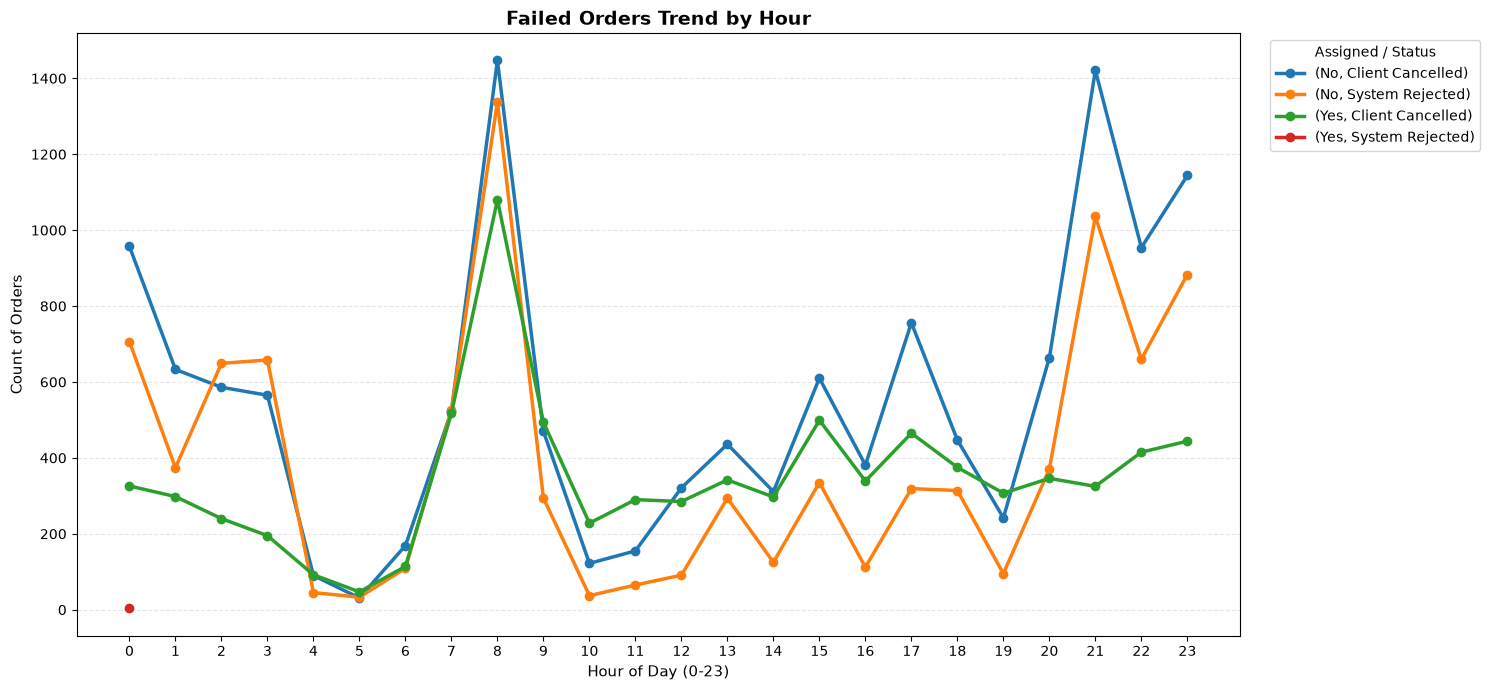

In [17]:
df['hour'] =df['order_datetime'].dt.hour
df_grouped_by_hour_and_catogory = df.groupby(['hour', 'is_driver_assigned_key','order_status_key']).size()
print(df_grouped_by_hour_and_catogory)

df_unstacked = df_grouped_by_hour_and_catogory.unstack(level=["is_driver_assigned_key", "order_status_key"])

# 2. الرسم
ax = df_unstacked.plot(figsize=(15, 7), marker="o", linewidth=2.5)

plt.xticks(range(0, 24))
plt.title("Failed Orders Trend by Hour", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day (0-23)", fontsize=11)
plt.ylabel("Count of Orders", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Assigned / Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Plot the average time to cancellation with and without driver, by the hour.
#### If there are any outliers in the data, it would be better to remove them. Can we draw any conclusions from this plot?

hour  is_driver_assigned_key
0     No                        115.126437
      Yes                       276.082822
1     No                        100.593997
      Yes                       296.312081
2     No                        121.305461
      Yes                       301.466667
3     No                        129.182301
      Yes                       368.682051
4     No                        100.733333
      Yes                       245.250000
5     No                        102.838710
      Yes                       156.617021
6     No                        202.952663
      Yes                       225.508772
7     No                        141.177820
      Yes                       177.640232
8     No                        132.625432
      Yes                       172.896296
9     No                        138.014894
      Yes                       230.821862
10    No                         93.795082
      Yes                       206.447368
11    No                 

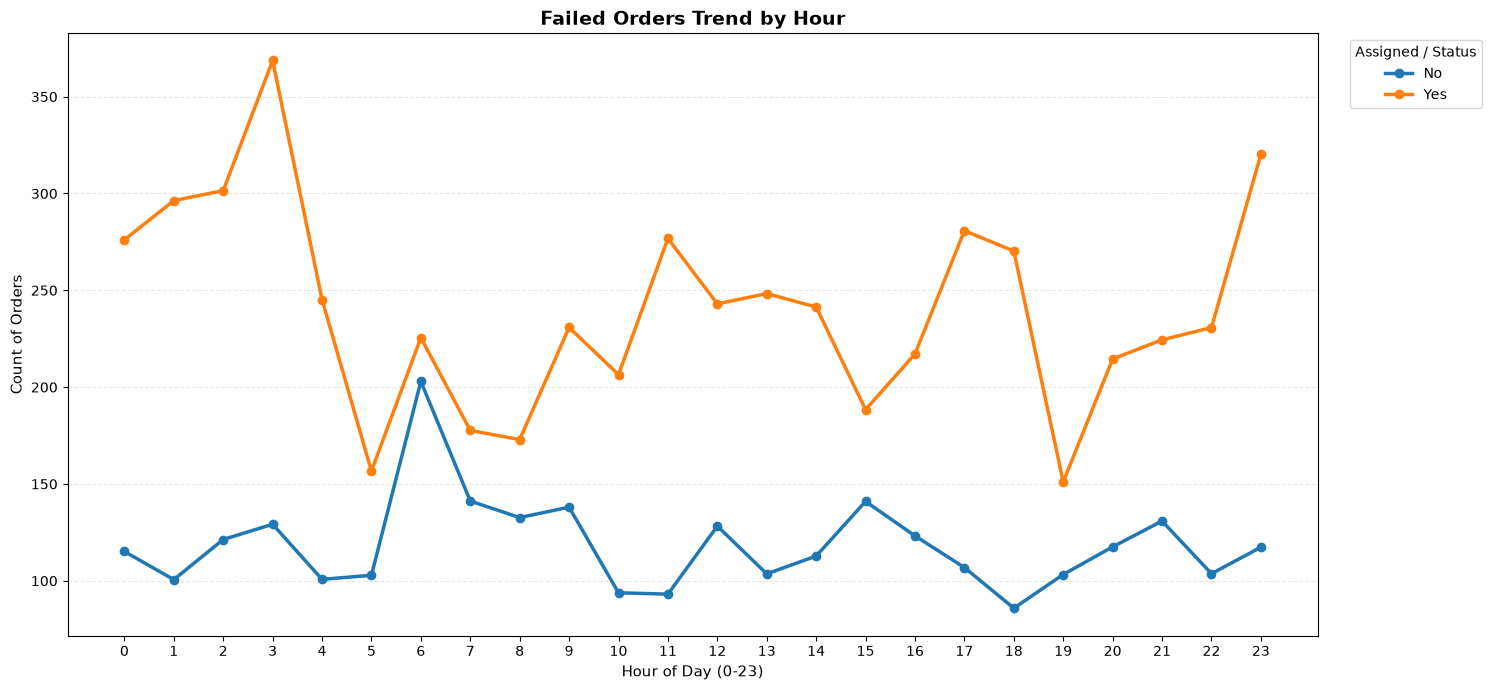

In [18]:
df_grouped_by_hour_and_driver_key = df.groupby(['hour','is_driver_assigned_key'])['cancellations_time_in_seconds'].mean()
print(df_grouped_by_hour_and_driver_key)
df_grouped_by_hour_and_driver_key_unstacked = df_grouped_by_hour_and_driver_key.unstack(level=['is_driver_assigned_key'])
ax = df_grouped_by_hour_and_driver_key_unstacked.plot(figsize=(15, 7), marker="o", linewidth=2.5)

plt.xticks(range(0, 24))
plt.title("Failed Orders Trend by Hour", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day (0-23)", fontsize=11)
plt.ylabel("Count of Orders", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Assigned / Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Plot the distribution of average ETA by hours.
#### How can this plot be explained?

hour
0     375.433333
1     355.322148
2     389.554167
3     381.492308
4     266.119565
5     476.787234
6     489.456140
7     642.746615
8     671.086111
9     556.085020
10    424.969298
11    405.837931
12    504.691228
13    445.228070
14    406.383838
15    518.218437
16    456.958702
17    548.673118
18    421.725333
19    396.850163
20    299.627168
21    365.630769
22    365.896386
23    386.078829
Name: m_order_eta, dtype: float64


C:\Users\Sara\AppData\Local\Temp\ipykernel_21936\3910829699.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Assigned / Status", bbox_to_anchor=(1.02, 1), loc="upper left")


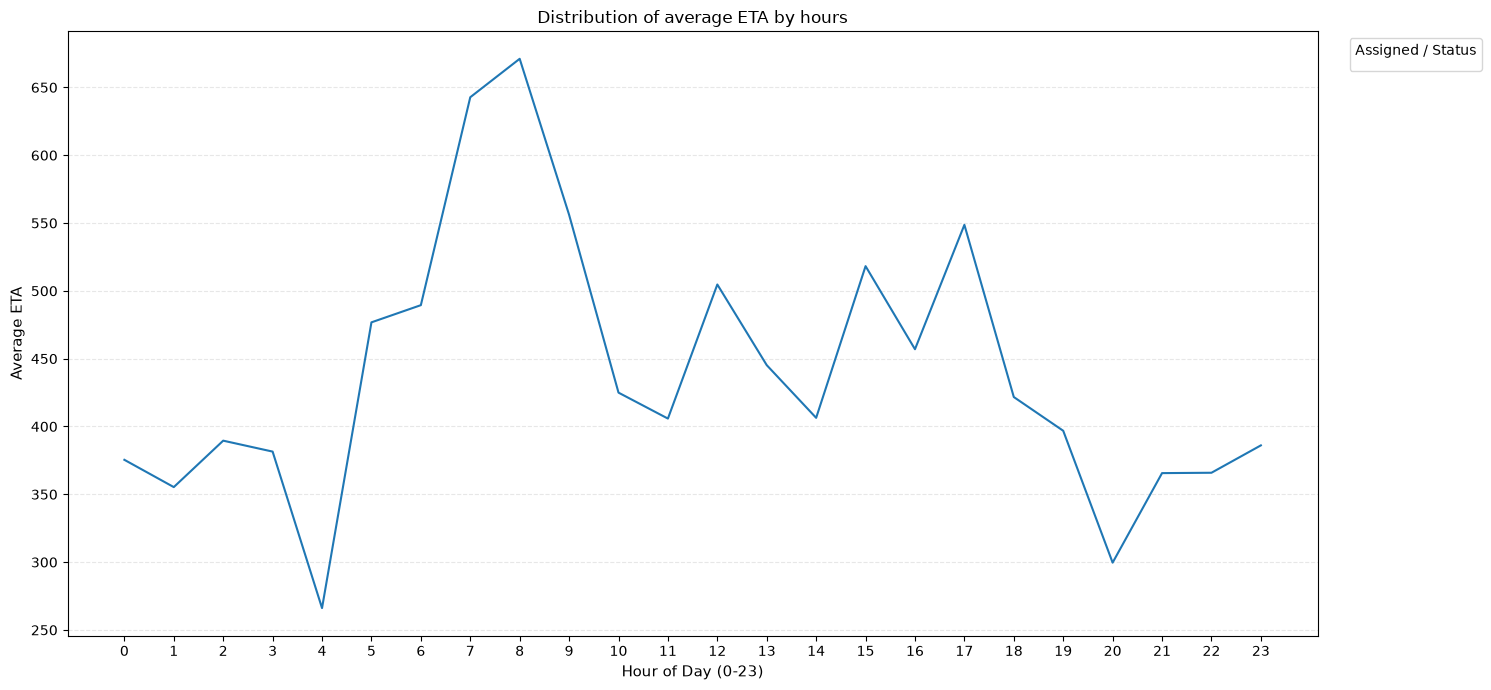

In [19]:
df_average_ETA = df.groupby('hour')['m_order_eta'].mean()
print(df_average_ETA)

plt.figure(figsize=(15,7))
plt.plot(df_average_ETA.index, df_average_ETA.values)
plt.xticks(range(0,24))
plt.title('Distribution of average ETA by hours')
plt.xlabel("Hour of Day (0-23)", fontsize=11)
plt.ylabel("Average ETA", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Assigned / Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### BONUS Hexagons. 
#### Using the h3 and folium packages, calculate how many sizes 8 hexes contain 80% of all orders from the original data sets and visualise the hexes, colouring them by the number of fails on the map.

In [20]:
vec_latlng_to_cell = np.vectorize(h3.latlng_to_cell)

df['hex_id'] = vec_latlng_to_cell(df['origin_latitude'], df['origin_longitude'], res=8)
df.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds,offer_id,hour,hex_id
0,1900-01-01 18:08:07,-0.978916,51.456173,60.0,3000583041974,Client Cancelled,Yes,198.0,300050983403,18,88195d2b03fffff
1,1900-01-01 20:57:32,-0.950385,51.456843,NaN,3000583116437,Client Cancelled,No,128.0,300050986179,20,88195d2b19fffff
2,1900-01-01 20:57:32,-0.950385,51.456843,NaN,3000583116437,Client Cancelled,No,128.0,300050986174,20,88195d2b19fffff
3,1900-01-01 20:57:32,-0.950385,51.456843,NaN,3000583116437,Client Cancelled,No,128.0,300050986180,20,88195d2b19fffff
4,1900-01-01 12:07:50,-0.969520,51.455544,477.0,3000582891479,Client Cancelled,Yes,46.0,300050976275,12,88195d2b1dfffff


In [28]:

df_grouped_by_hex_id = df.groupby('hex_id')['order_gk'].count().sort_values()

#print(df_grouped_by_hex_id)
df_grouped_by_hex_id['Cum_Percentage'] = (df_grouped_by_hex_id.cumsum() / df_grouped_by_hex_id.sum()) * 100

print(df_grouped_by_hex_id)


hex_id
88195d282bfffff                                                    1
88195d2953fffff                                                    1
88195d3993fffff                                                    1
88195d2aebfffff                                                    1
88195d74d5fffff                                                    1
                                         ...                        
88195d2b11fffff                                                 2191
88195d2b15fffff                                                 2461
88195d2b1bfffff                                                 2603
88195d2b1dfffff                                                 4488
Cum_Percentage     hex_id
88195d282bfffff      0.003198
88195d295...
Name: order_gk, Length: 140, dtype: object


In [21]:

# 1. Convert GPS coordinates to H3 Hex IDs (Vectorized for high performance)
vec_latlng_to_cell = np.vectorize(h3.latlng_to_cell)
df['hex_id'] = vec_latlng_to_cell(df['origin_latitude'], df['origin_longitude'], res=8)

# 2. Group by hex_id, count orders, sort ascending, and reset index
df_grouped_by_hex_id = (
    df.groupby('hex_id')['order_gk']
    .count()
    .sort_values(ascending=True)
    .reset_index(name='order_count')
)

# 3. Calculate running total percentage (Cumulative Percentage)
df_grouped_by_hex_id['Cum_Percentage'] = (
    df_grouped_by_hex_id['order_count'].cumsum() / df_grouped_by_hex_id['order_count'].sum()
) * 100

# 4. Filter hexes that cover up to the bottom 80% of total orders
hexes_80_percent = df_grouped_by_hex_id[df_grouped_by_hex_id['Cum_Percentage'] <= 80]
print(f"Number of hexes covering the first 80% of orders: {len(hexes_80_percent)}")

# 5. Extract the top busiest hexes accounting for the remaining 20%
top_hexes = df_grouped_by_hex_id[df_grouped_by_hex_id['Cum_Percentage'] > 80]
print("\nBusiest hexes causing the majority of order failures (Top Bottlenecks):")
print(top_hexes)

Number of hexes covering the first 80% of orders: 137

Busiest hexes causing the majority of order failures (Top Bottlenecks):
              hex_id  order_count  Cum_Percentage
137  88195d2b1bfffff         2603       85.646668
138  88195d2b1dfffff         4488      100.000000


In [ ]:
import folium

tiles_url = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}'
attr = 'Tiles &copy; Esri &mdash; Source: Esri, DeLorme, NAVTEQ, USGS, Intermap, iPC, NRCAN, Esri Japan, METI, Esri China (Hong Kong), Esri (Thailand), TomTom, 2012'
m = folium.Map(
    location=[df['origin_latitude'].mean(), df['origin_longitude'].mean()],
    zoom_start=12,
    tiles=tiles_url,
    attr=attr
)


for _, row in df_grouped_by_hex_id.iterrows():
    hex_id = row['hex_id']
    cum_pct = row['Cum_Percentage']
    color = 'red' if cum_pct > 80 else 'blue'
    boundary = h3.cell_to_boundary(hex_id)
    
    folium.Polygon(
        locations=boundary,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.4,
        popup=f"Hex: {hex_id}<br>Orders: {row['order_count']}"
    ).add_to(m)

m.save("map.html")
m